<a href="https://colab.research.google.com/github/jmkoveleski-byte/github-starter/blob/main/Spotify_Data_Description_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving dataset.csv to dataset.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

In [ ]:
df = pd.read_csv("dataset.csv")

print(df.shape)
df.head()

(114000, 21)


,Unnamed: 0,song_id,artists,album_name,song_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,song_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [ ]:
#Data Overview
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   song_id           114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   song_name         113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

In [ ]:
df.describe()

,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,56999.500000,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,32909.109681,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28499.750000,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,56999.500000,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,85499.250000,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,113999.000000,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


In [ ]:
#Data set summary
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 114000
Columns: 21


In [ ]:
#Missing Values Anakysis
missing = df.isnull().sum()

missing = missing[missing > 0]

missing.sort_values(ascending=False)

,0
artists,1
album_name,1
song_name,1


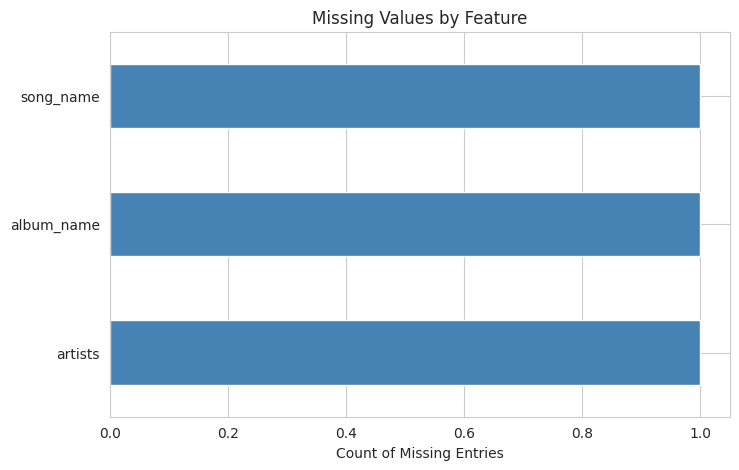

In [ ]:
# Visualize missing values
missing.sort_values().plot(
    kind="barh",
    figsize=(8, 5),
    color="steelblue"
)
plt.title("Missing Values by Feature")
plt.xlabel("Count of Missing Entries")
plt.show()

In [ ]:
# Total exact duplicate rows
duplicates = df.duplicated().sum()
print("Duplicate Rows:", duplicates)

# Duplicate song IDs across genres/entries
song_ids = df["song_id"].duplicated().sum()
print("Duplicate Song IDs:", song_ids)

# Sample duplicate track entries
df[df["song_id"].duplicated(keep=False)].sort_values("song_id").head(20)

Duplicate Rows: 0
Duplicate Song IDs: 24259


,Unnamed: 0,song_id,artists,album_name,song_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,song_genre
15028,15028,001APMDOl3qtx1526T11n1,Pink Sweat$;Kirby,New RnB,Better,0,176320,False,0.613,0.471,...,-6.644,0,0.1070,0.31600,0.000001,0.1170,0.406,143.064,4,chill
103211,103211,001APMDOl3qtx1526T11n1,Pink Sweat$;Kirby,New RnB,Better,0,176320,False,0.613,0.471,...,-6.644,0,0.1070,0.31600,0.000001,0.1170,0.406,143.064,4,soul
85578,85578,001YQlnDSduXd5LgBd66gT,Soda Stereo,Soda Stereo (Remastered),El Tiempo Es Dinero - Remasterizado 2007,38,177266,False,0.554,0.921,...,-4.589,1,0.0758,0.01940,0.088100,0.3290,0.700,183.571,1,punk-rock
100420,100420,001YQlnDSduXd5LgBd66gT,Soda Stereo,Soda Stereo (Remastered),El Tiempo Es Dinero - Remasterizado 2007,38,177266,False,0.554,0.921,...,-4.589,1,0.0758,0.01940,0.088100,0.3290,0.700,183.571,1,ska
91801,91801,003vvx7Niy0yvhvHt4a68B,The Killers,Hot Fuss,Mr. Brightside,86,222973,False,0.352,0.911,...,-5.230,1,0.0747,0.00121,0.000000,0.0995,0.236,148.033,4,rock
3257,3257,003vvx7Niy0yvhvHt4a68B,The Killers,Hot Fuss,Mr. Brightside,86,222973,False,0.352,0.911,...,-5.230,1,0.0747,0.00121,0.000000,0.0995,0.236,148.033,4,alternative
2106,2106,003vvx7Niy0yvhvHt4a68B,The Killers,Hot Fuss,Mr. Brightside,86,222973,False,0.352,0.911,...,-5.230,1,0.0747,0.00121,0.000000,0.0995,0.236,148.033,4,alt-rock
33178,33178,004h8smbIoAkUNDJvVKwkG,Ouse;Powfu,Loners Diary,Lovemark,58,219482,True,0.808,0.331,...,-13.457,1,0.0557,0.13100,0.000000,0.2250,0.337,140.035,4,emo
94239,94239,004h8smbIoAkUNDJvVKwkG,Ouse;Powfu,Loners Diary,Lovemark,58,219482,True,0.808,0.331,...,-13.457,1,0.0557,0.13100,0.000000,0.2250,0.337,140.035,4,sad
97533,97533,006rHBBNLJMpQs8fRC2GDe,Calcinha Preta;Gusttavo Lima,CP 25 Anos (Ao Vivo em Aracaju),Agora Estou Sofrendo - Ao Vivo,47,260510,False,0.605,0.678,...,-3.257,1,0.0311,0.64200,0.000000,0.1570,0.439,125.059,4,sertanejo


In [ ]:
# Total exact duplicate rows
duplicates = df.duplicated().sum()
print("Duplicate Rows:", duplicates)

# Duplicate song IDs across genres/entries
song_ids = df["song_id"].duplicated().sum()
print("Duplicate Song IDs:", song_ids)

# Sample duplicate track entries
df[df["song_id"].duplicated(keep=False)].sort_values("song_id").head(20)

Duplicate Rows: 0
Duplicate Song IDs: 24259


,Unnamed: 0,song_id,artists,album_name,song_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,song_genre
15028,15028,001APMDOl3qtx1526T11n1,Pink Sweat$;Kirby,New RnB,Better,0,176320,False,0.613,0.471,...,-6.644,0,0.1070,0.31600,0.000001,0.1170,0.406,143.064,4,chill
103211,103211,001APMDOl3qtx1526T11n1,Pink Sweat$;Kirby,New RnB,Better,0,176320,False,0.613,0.471,...,-6.644,0,0.1070,0.31600,0.000001,0.1170,0.406,143.064,4,soul
85578,85578,001YQlnDSduXd5LgBd66gT,Soda Stereo,Soda Stereo (Remastered),El Tiempo Es Dinero - Remasterizado 2007,38,177266,False,0.554,0.921,...,-4.589,1,0.0758,0.01940,0.088100,0.3290,0.700,183.571,1,punk-rock
100420,100420,001YQlnDSduXd5LgBd66gT,Soda Stereo,Soda Stereo (Remastered),El Tiempo Es Dinero - Remasterizado 2007,38,177266,False,0.554,0.921,...,-4.589,1,0.0758,0.01940,0.088100,0.3290,0.700,183.571,1,ska
91801,91801,003vvx7Niy0yvhvHt4a68B,The Killers,Hot Fuss,Mr. Brightside,86,222973,False,0.352,0.911,...,-5.230,1,0.0747,0.00121,0.000000,0.0995,0.236,148.033,4,rock
3257,3257,003vvx7Niy0yvhvHt4a68B,The Killers,Hot Fuss,Mr. Brightside,86,222973,False,0.352,0.911,...,-5.230,1,0.0747,0.00121,0.000000,0.0995,0.236,148.033,4,alternative
2106,2106,003vvx7Niy0yvhvHt4a68B,The Killers,Hot Fuss,Mr. Brightside,86,222973,False,0.352,0.911,...,-5.230,1,0.0747,0.00121,0.000000,0.0995,0.236,148.033,4,alt-rock
33178,33178,004h8smbIoAkUNDJvVKwkG,Ouse;Powfu,Loners Diary,Lovemark,58,219482,True,0.808,0.331,...,-13.457,1,0.0557,0.13100,0.000000,0.2250,0.337,140.035,4,emo
94239,94239,004h8smbIoAkUNDJvVKwkG,Ouse;Powfu,Loners Diary,Lovemark,58,219482,True,0.808,0.331,...,-13.457,1,0.0557,0.13100,0.000000,0.2250,0.337,140.035,4,sad
97533,97533,006rHBBNLJMpQs8fRC2GDe,Calcinha Preta;Gusttavo Lima,CP 25 Anos (Ao Vivo em Aracaju),Agora Estou Sofrendo - Ao Vivo,47,260510,False,0.605,0.678,...,-3.257,1,0.0311,0.64200,0.000000,0.1570,0.439,125.059,4,sertanejo


Songs with Popularity = 0: 16020
Percent: 14.05 %


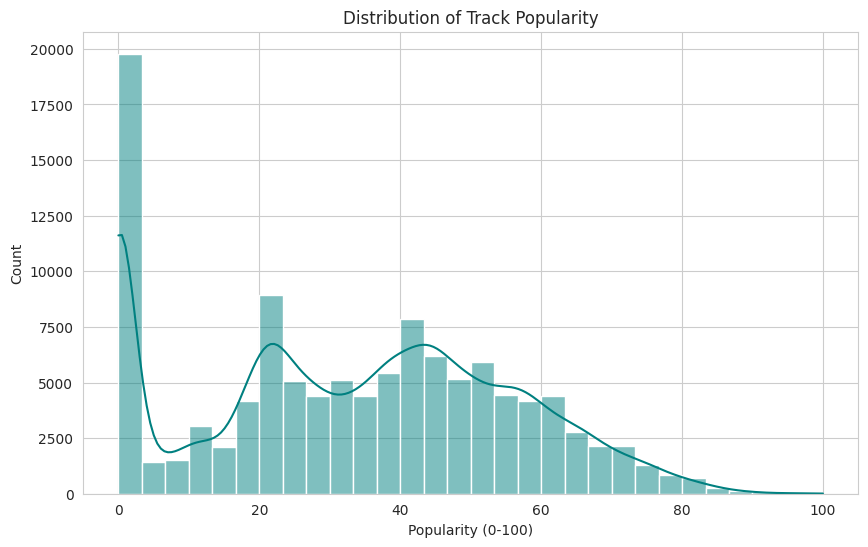

In [ ]:
# Count tracks where popularity == 0
zero_pop = (df["popularity"] == 0).sum()
print("Songs with Popularity = 0:", zero_pop)
print("Percent:", round(zero_pop / len(df) * 100, 2), "%")

# Distribution histogram
sns.histplot(df["popularity"], bins=30, kde=True, color="teal")
plt.title("Distribution of Track Popularity")
plt.xlabel("Popularity (0-100)")
plt.ylabel("Count")
plt.show()

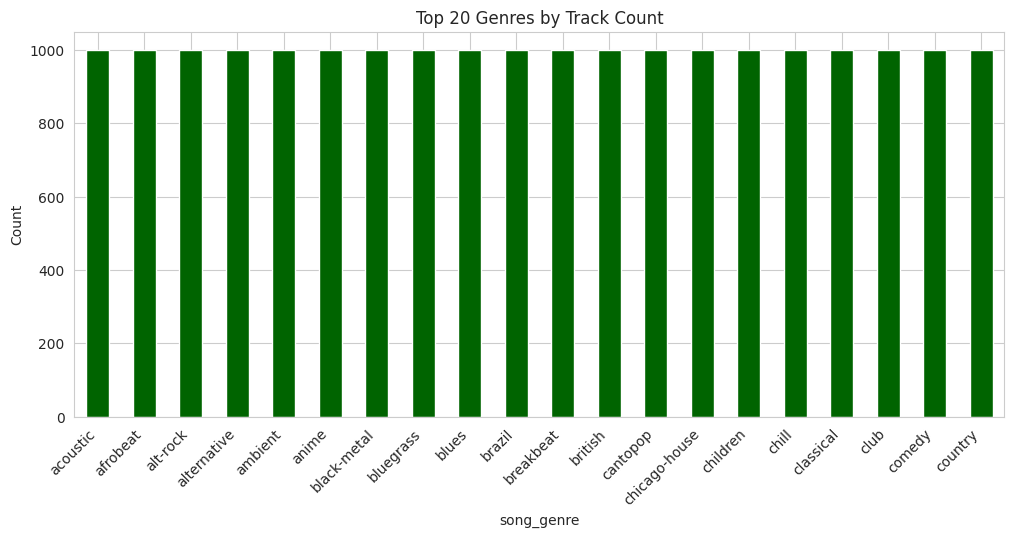

In [ ]:
# Top 20 genres representation
top_genres = df["song_genre"].value_counts().head(20)

top_genres.plot(
    kind="bar",
    color="darkgreen",
    figsize=(12, 5)
)
plt.title("Top 20 Genres by Track Count")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.show()

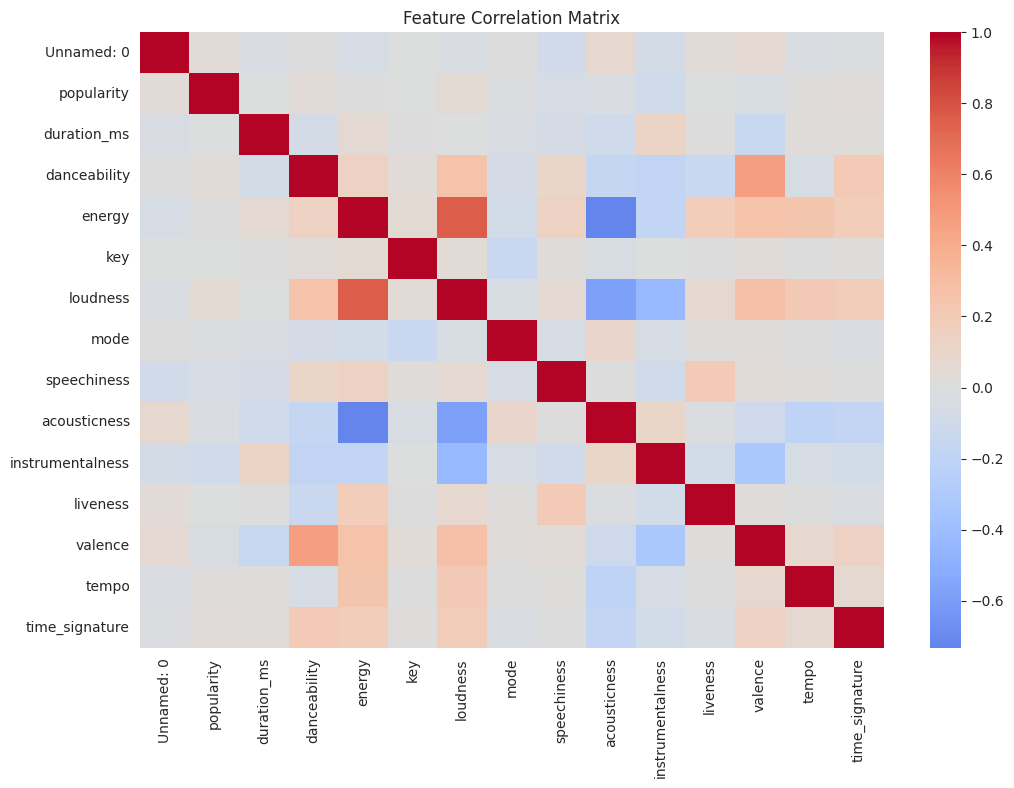

Correlation with Popularity:
 popularity          1.000000
loudness            0.050423
danceability        0.035448
Unnamed: 0          0.032142
time_signature      0.031073
tempo               0.013205
energy              0.001056
key                -0.003853
liveness           -0.005387
duration_ms        -0.007101
mode               -0.013931
acousticness       -0.025472
valence            -0.040534
speechiness        -0.044927
instrumentalness   -0.095139
Name: popularity, dtype: float64


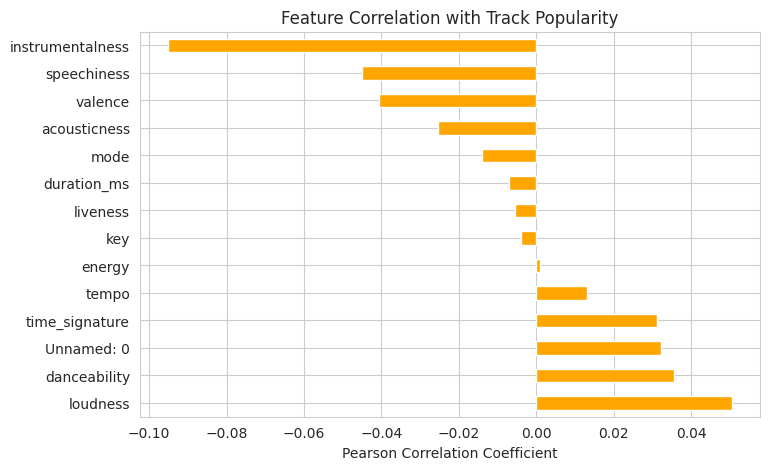

In [ ]:
# Select numeric columns and compute correlation matrix
numeric_df = df.select_dtypes(include=["int64", "float64"])
corr = numeric_df.corr(numeric_only=True)

# Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)
plt.title("Feature Correlation Matrix")
plt.show()

# Rank features by correlation with popularity
corr_popularity = corr["popularity"].sort_values(ascending=False)
print("Correlation with Popularity:\n", corr_popularity)

# Horizontal bar chart
plt.figure(figsize=(8, 5))
corr_popularity.drop("popularity").plot(kind="barh", color="orange")
plt.title("Feature Correlation with Track Popularity")
plt.xlabel("Pearson Correlation Coefficient")
plt.show()

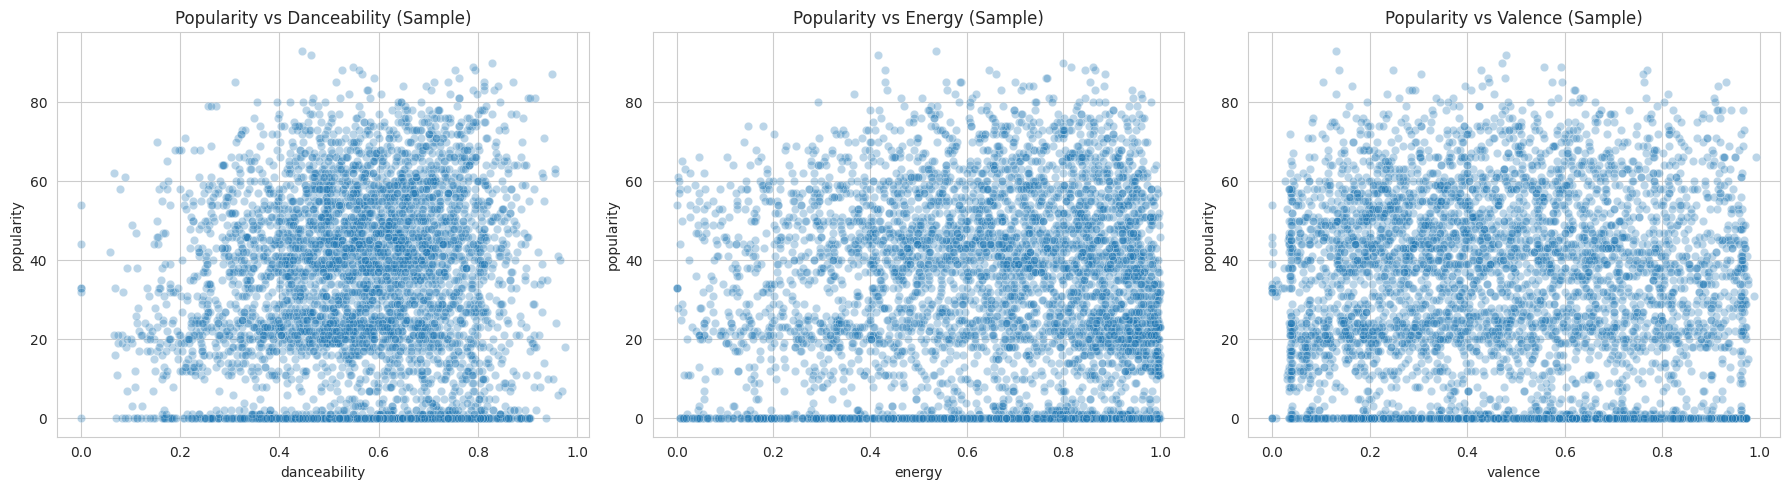

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Danceability
sns.scatterplot(data=df.sample(5000, random_state=42), x="danceability", y="popularity", alpha=0.3, ax=axes[0])
axes[0].set_title("Popularity vs Danceability (Sample)")

# Energy
sns.scatterplot(data=df.sample(5000, random_state=42), x="energy", y="popularity", alpha=0.3, ax=axes[1])
axes[1].set_title("Popularity vs Energy (Sample)")

# Valence
sns.scatterplot(data=df.sample(5000, random_state=42), x="valence", y="popularity", alpha=0.3, ax=axes[2])
axes[2].set_title("Popularity vs Valence (Sample)")

plt.tight_layout()
plt.show()

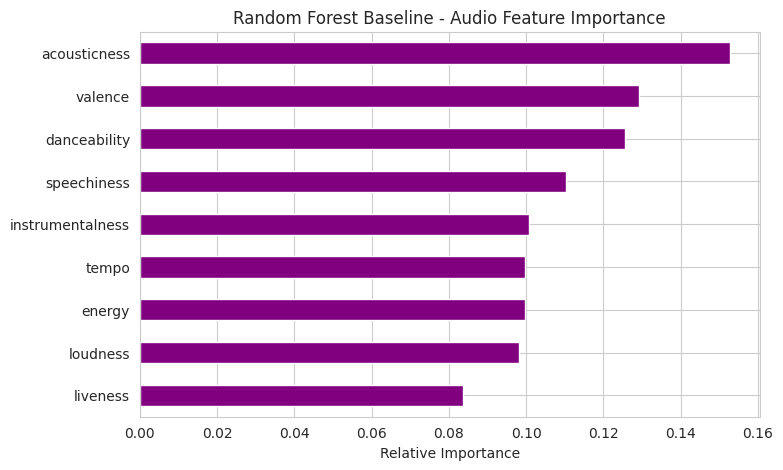

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

# Select features and target
features = [
    'danceability', 'energy', 'loudness', 'speechiness',
    'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo'
]

X = df[features]
y = df["popularity"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Baseline model
model = RandomForestRegressor(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

# Feature Importance
importance = pd.Series(model.feature_importances_, index=features).sort_values()

importance.plot(kind="barh", color="purple", figsize=(8, 5))
plt.title("Random Forest Baseline - Audio Feature Importance")
plt.xlabel("Relative Importance")
plt.show()